# Contingency Analysis in Transmission Grids

Contingency analysis is a critical process in power system operations used to assess the impact of potential failures (e.g., line outages) on grid stability and reliability. It helps operators prepare for unexpected events by simulating scenarios such as N-1 or N-2 contingencies, where one or more components are removed from service. This analysis ensures that the grid can continue to operate within safe limits even under stressed conditions.

---

## Dataset Generation and Model Evaluation

The dataset used in this study originates from the Texas transmission grid, which includes approximately 2,000 nodes. Using the contingency mode of the `gridfm-datakit`, we simulated N-2 contingencies by removing up to two transmission lines at a time. For each scenario, we first solved the optimal power flow (OPF) problem to determine the generation dispatch. Then, we applied the contingency by removing lines and re-solved the power flow to observe the resulting grid state.

This process generated around 100,000 unique scenarios. Our model, **GENCO**, was trained on this dataset to predict power flow outcomes. For demonstration purposes, we selected a subsample of 181 scenarios. The `gridfm-datakit` also computed DC power flow results, enabling a comparison between GENCO predictions and traditional DC power flow estimates, specifically in terms of line loading accuracy.

All predictions are benchmarked against the ground truth obtained from AC power flow simulations. Additionally, we analyze bus voltage violations, which GridFM can predict but are not captured by the DC solver, highlighting GENCO’s enhanced capabilities in modeling grid behavior.


In [ ]:
# Only run this cell if running on Colab.
import sys

if "google.colab" in sys.modules:
    try:
        #!git clone https://github.com/gridfm/gridfm-graphkit.git   CHANGE IF WE PUT THIS NOTEBOOK ON MAIN
        !git clone -b normalization_fixed_eval_predict https://github.com/gridfm/gridfm-graphkit.git
        !pip install ./gridfm-graphkit
    except Exception as e:
        print(f"Failed to start Google Collab setup, due to {e}")

# If running on Colab you will be asked to restart the session. This is normal and you should do so.


In [ ]:
%cd gridfm-graphkit/examples/notebooks/
%pwd

In [1]:
import os
import sys
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from contingency_utils import *
from pathlib import Path
sys.path.append("../")

if 'google.colab' in sys.modules:
  import gdown
  from google.colab import output
  output.enable_custom_widget_manager()

## Load Data

We load both the ground truth and predicted values of the power flow solution. The predictions are generated using the `gridfm-graphkit` CLI:

```bash
gridfm-graphkit predict ...
```

We then merge the datasets using `scenario` and `bus` as keys, allowing us to align the predicted and actual values for each grid state and bus.

In [ ]:
root_pred_folder = "../data/contingency/"
prediction_label = "predictionsv1"
label_plot = "GENCO"
data_path = Path("../data/contingency/")
data_path.mkdir(parents=True, exist_ok=True)

Download the sample data provided for this tutorial

In [ ]:
if 'google.colab' in sys.modules:
  try:
    !gdown 19gOdmVHou4NTbIch7tjtjynQpQHg1sLG -O ../data/contingency/texas_nminus2_small.zip
  except:
    print(f"Download failed via g.down!")
    # full data path
    # https://drive.google.com/file/d/19gOdmVHou4NTbIch7tjtjynQpQHg1sLG/view?usp=sharing

!unzip ../data/contingency/texas_nminus2_small.zip -d ../data/contingency/

In [3]:
preds = pd.read_parquet(os.path.join(root_pred_folder, "filtered_preds_light2.parquet"))
bus_data = pd.read_parquet(os.path.join(root_pred_folder, "filtered_bus_data_light2.parquet"))
branch_data = pd.read_parquet(os.path.join(root_pred_folder, "filtered_branch_data_light2.parquet"))

In [4]:
# Create one df for GT and preds
pf_node = preds.merge(bus_data, on=["scenario", "bus"], how="left")
pf_node.head()

,scenario,bus,Vm_pred,Va_pred,Vm,Va,Va_dc,PV,REF
0,192,0,0.972092,0.297237,0.971997,17.183649,22.736404,0.0,0.0
1,192,1,1.025311,0.407510,1.025286,23.582836,30.041912,0.0,0.0
2,192,2,0.980993,0.459173,0.980985,26.447821,31.870030,0.0,0.0
3,192,3,0.988535,0.432471,0.988535,24.905265,30.274750,1.0,0.0
4,192,4,0.996931,0.469589,0.996915,27.126643,33.319846,0.0,0.0


In [5]:
# Build GENCO/DC state variants used to compute comparable branch flows
pf_node["Vm_pred_corrected"] = pf_node["Vm_pred"].astype(np.float64)
pf_node["Va_pred_corrected"] = pf_node["Va_pred"]
pf_node["Vm_dc_corrected"] = np.ones(len(pf_node), dtype=np.float64)
pf_node["Va_dc_corrected"] = pf_node["Va_dc"]
# Branch-power function expects degree inputs
pf_node['Va_pred_corrected'] = np.rad2deg(pf_node['Va_pred_corrected'])
pf_node

,scenario,bus,Vm_pred,Va_pred,Vm,Va,Va_dc,PV,REF,Vm_pred_corrected,Va_pred_corrected,Vm_dc_corrected,Va_dc_corrected
0,192,0,0.972092,0.297237,0.971997,17.183649,22.736404,0.0,0.0,0.972092,17.030441,1.0,22.736404
1,192,1,1.025311,0.407510,1.025286,23.582836,30.041912,0.0,0.0,1.025311,23.348585,1.0,30.041912
2,192,2,0.980993,0.459173,0.980985,26.447821,31.870030,0.0,0.0,0.980993,26.308659,1.0,31.870030
3,192,3,0.988535,0.432471,0.988535,24.905265,30.274750,1.0,0.0,0.988535,24.778772,1.0,30.274750
4,192,4,0.996931,0.469589,0.996915,27.126643,33.319846,0.0,0.0,0.996931,26.905474,1.0,33.319846
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1737995,663,1995,1.005423,-0.040232,1.005784,-2.106279,0.287776,0.0,0.0,1.005423,-2.305096,1.0,0.287776
1737996,663,1996,0.998826,-0.082904,0.999000,-4.507781,-1.746393,0.0,0.0,0.998826,-4.750057,1.0,-1.746393
1737997,663,1997,1.005303,-0.017626,1.006268,-0.856848,1.080400,0.0,0.0,1.005303,-1.009888,1.0,1.080400
1737998,663,1998,1.007550,-0.049535,1.008352,-2.661804,-0.551765,0.0,0.0,1.007550,-2.838135,1.0,-0.551765


## Compute branch current and line loading

In [6]:
# Compute per-branch loading for AC ground truth, GENCO prediction, and DC baseline.
rated_branch_data = branch_data[branch_data["rate_a"] > 0].copy()
# Stress-test: reducing thermal limits increases normalized loading values.
rate_a = rated_branch_data["rate_a"].to_numpy(dtype=np.float64) / 1.25

loadings_map = {}
for flag in ("gt", "pred", "dc"):
    pf, qf, pt, qt = compute_branch_powers_vectorized(
        rated_branch_data,
        pf_node,
        sn_mva=100.0,
        flag=flag,
    )
    s_from = np.hypot(pf, qf)
    s_to = np.hypot(pt, qt)
    loadings_map[flag] = (np.maximum(s_from, s_to) / rate_a).flatten()

loadings = loadings_map["gt"]
loadings_genco = loadings_map["pred"]
loadings_dc = loadings_map["dc"]

In [7]:
loadings = loadings.flatten()
loadings_pred = loadings_genco.flatten()
loadings_dc = loadings_dc.flatten()

overloadings_mask = (loadings > 1.0)
overloadings_pred_mask = (loadings_pred > 0.988)
overloadings_dc_mask = (loadings_dc > 0.944)

## Compute metrics for overloading classification for GridFM and DC PF
- Below are the results of GENCO for overloading classification (HGNS version)
- Ground truth is AC PF.

In [8]:
TP_genco, FP_genco, TN_genco, FN_genco = compute_cm_metrics(
    overloadings_mask, overloadings_pred_mask, prediction_label, label_plot
)

Accuracy: 1.000
Confusion Matrix:
TP: 18979, FP: 870, TN: 2778322, FN: 9
GENCO
TPR: 1.000 (percentage of overloadings correctly predicted)
FPR: 0.000 (percentage of non-overloadings predicted as overloadings)
TNR: 1.00
FNR: 0.00


- Below are the results of DC PF for overloading classification
- Ground truth is AC PF.
- We use a threshold of 0.95 to make sure we identify all overloads

In [9]:
TP_dc, FP_dc, TN_dc, FN_dc = compute_cm_metrics(
    overloadings_mask, overloadings_dc_mask, "DC", label_plot
)

Accuracy: 0.996
Confusion Matrix:
TP: 18949, FP: 10007, TN: 2769185, FN: 39
GENCO
TPR: 0.998 (percentage of overloadings correctly predicted)
FPR: 0.004 (percentage of non-overloadings predicted as overloadings)
TNR: 1.00
FNR: 0.00


## Histogram of true line loadings

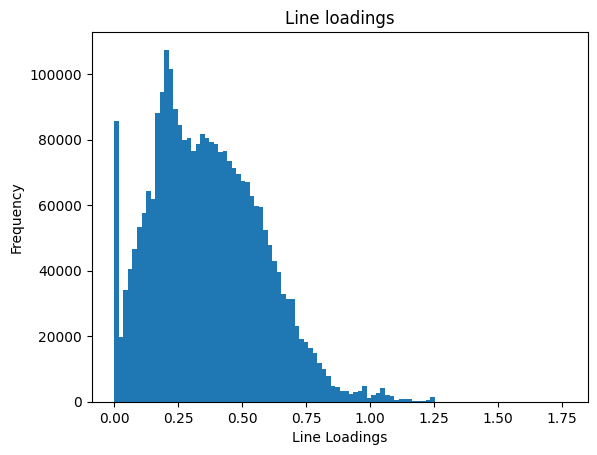

In [10]:
plt.hist(loadings, bins=100)
plt.xlabel("Line Loadings")
plt.ylabel("Frequency")
plt.title("Line loadings")
# log scale
plt.savefig(f"loadings_histogram_{prediction_label}.png")
plt.show()

## Predicted vs True line loading

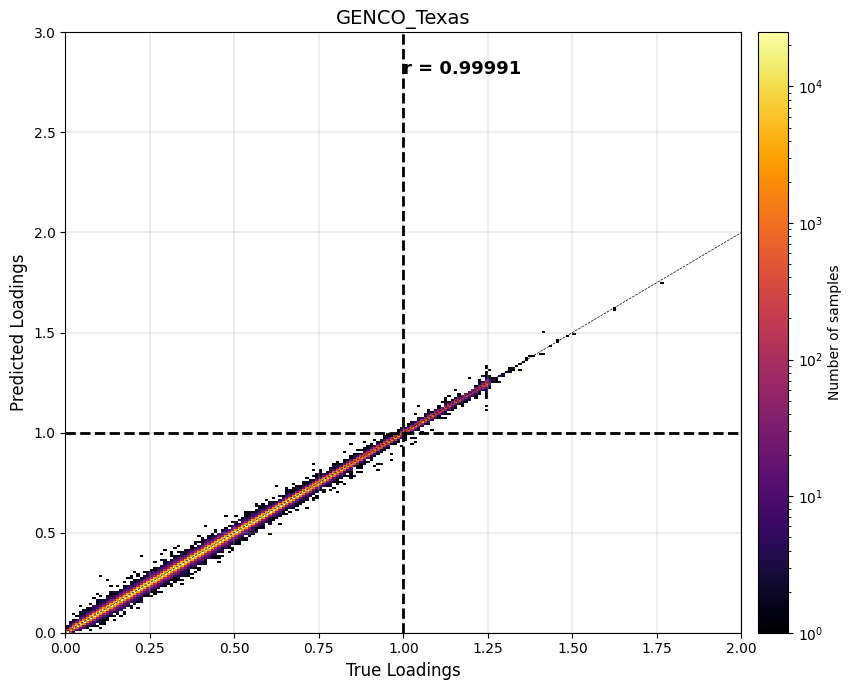

In [11]:
true_vals = loadings
gfm_vals = loadings_pred
dc_vals = loadings_dc

plot_mass_correlation_density(true_vals, gfm_vals, prediction_label, label_plot)

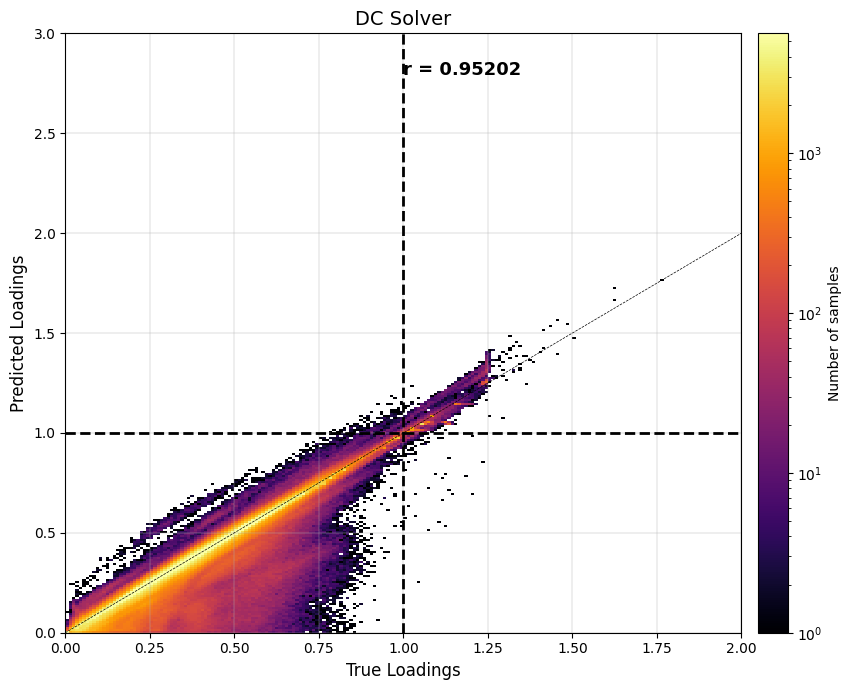

In [12]:
plot_mass_correlation_density(true_vals, dc_vals, "DC", "DC Solver")

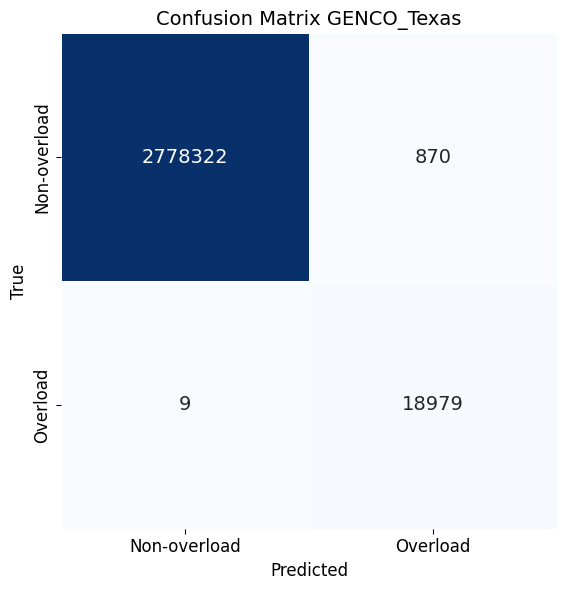

In [13]:
plot_cm(TN_genco, FP_genco, FN_genco, TP_genco, prediction_label, label_plot)

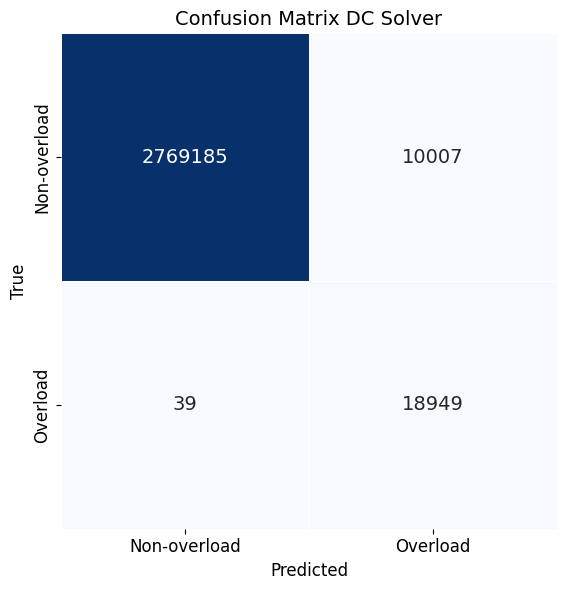

In [14]:
plot_cm(TN_dc, FP_dc, FN_dc, TP_dc, "DC", "DC Solver")

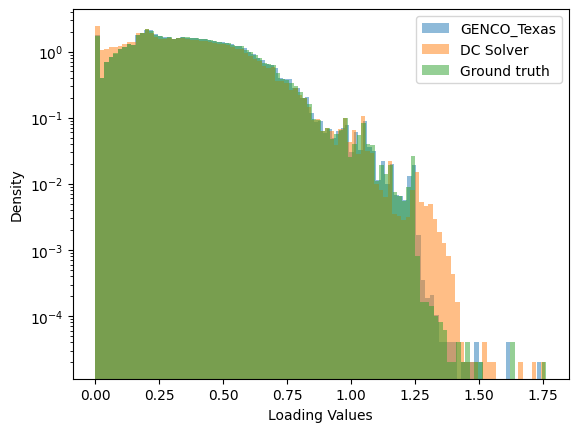

In [15]:
# Histograms of loadings
plot_loading_predictions(
    loadings_pred,
    loadings_dc,
    loadings,
    prediction_label,
    label_plot,
)

/dccstor/gridfm/tamara/modelling/updates/new_eval/gridfm-graphkit/venv/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/dccstor/gridfm/tamara/modelling/updates/new_eval/gridfm-graphkit/venv/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


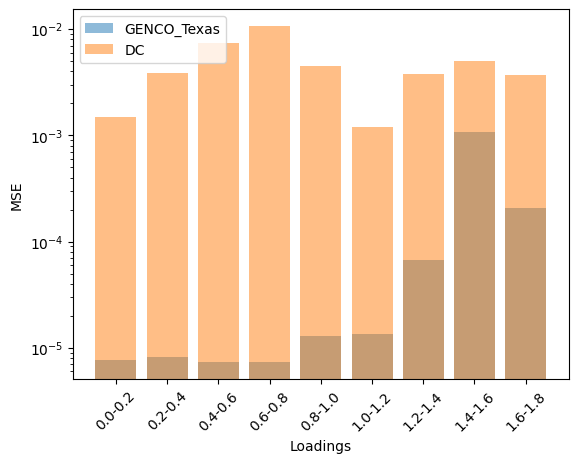

In [16]:
# make bar plot of wrongly classified loadings for different bins
bins = np.arange(0, 2.2, 0.2)
mse_pred = []
mse_dc = []
for i in range(len(bins) - 1):
    idx_in_bins = (loadings > bins[i]) & (
        loadings< bins[i + 1]
    )
    mse_pred.append(
        np.mean(
            (
                loadings_pred[idx_in_bins]
                - loadings[idx_in_bins]
            )
            ** 2
        )
    )
    mse_dc.append(
        np.mean(
            (
                loadings_dc[idx_in_bins]
                - loadings[idx_in_bins]
            )
            ** 2
        )
    )
# labels
labels = [f"{bins[i]:.1f}-{bins[i + 1]:.1f}" for i in range(len(bins) - 1)]
plt.bar(labels, mse_pred, label=label_plot, alpha=0.5)
plt.bar(labels, mse_dc, label="DC", alpha=0.5)
plt.legend()
plt.xlabel("Loadings")
plt.ylabel("MSE")
# y log scale
plt.yscale("log")
# rotate x labels
plt.xticks(rotation=45)
plt.savefig(f"loading_mse_{prediction_label}.png")
plt.show()

## Voltage violations

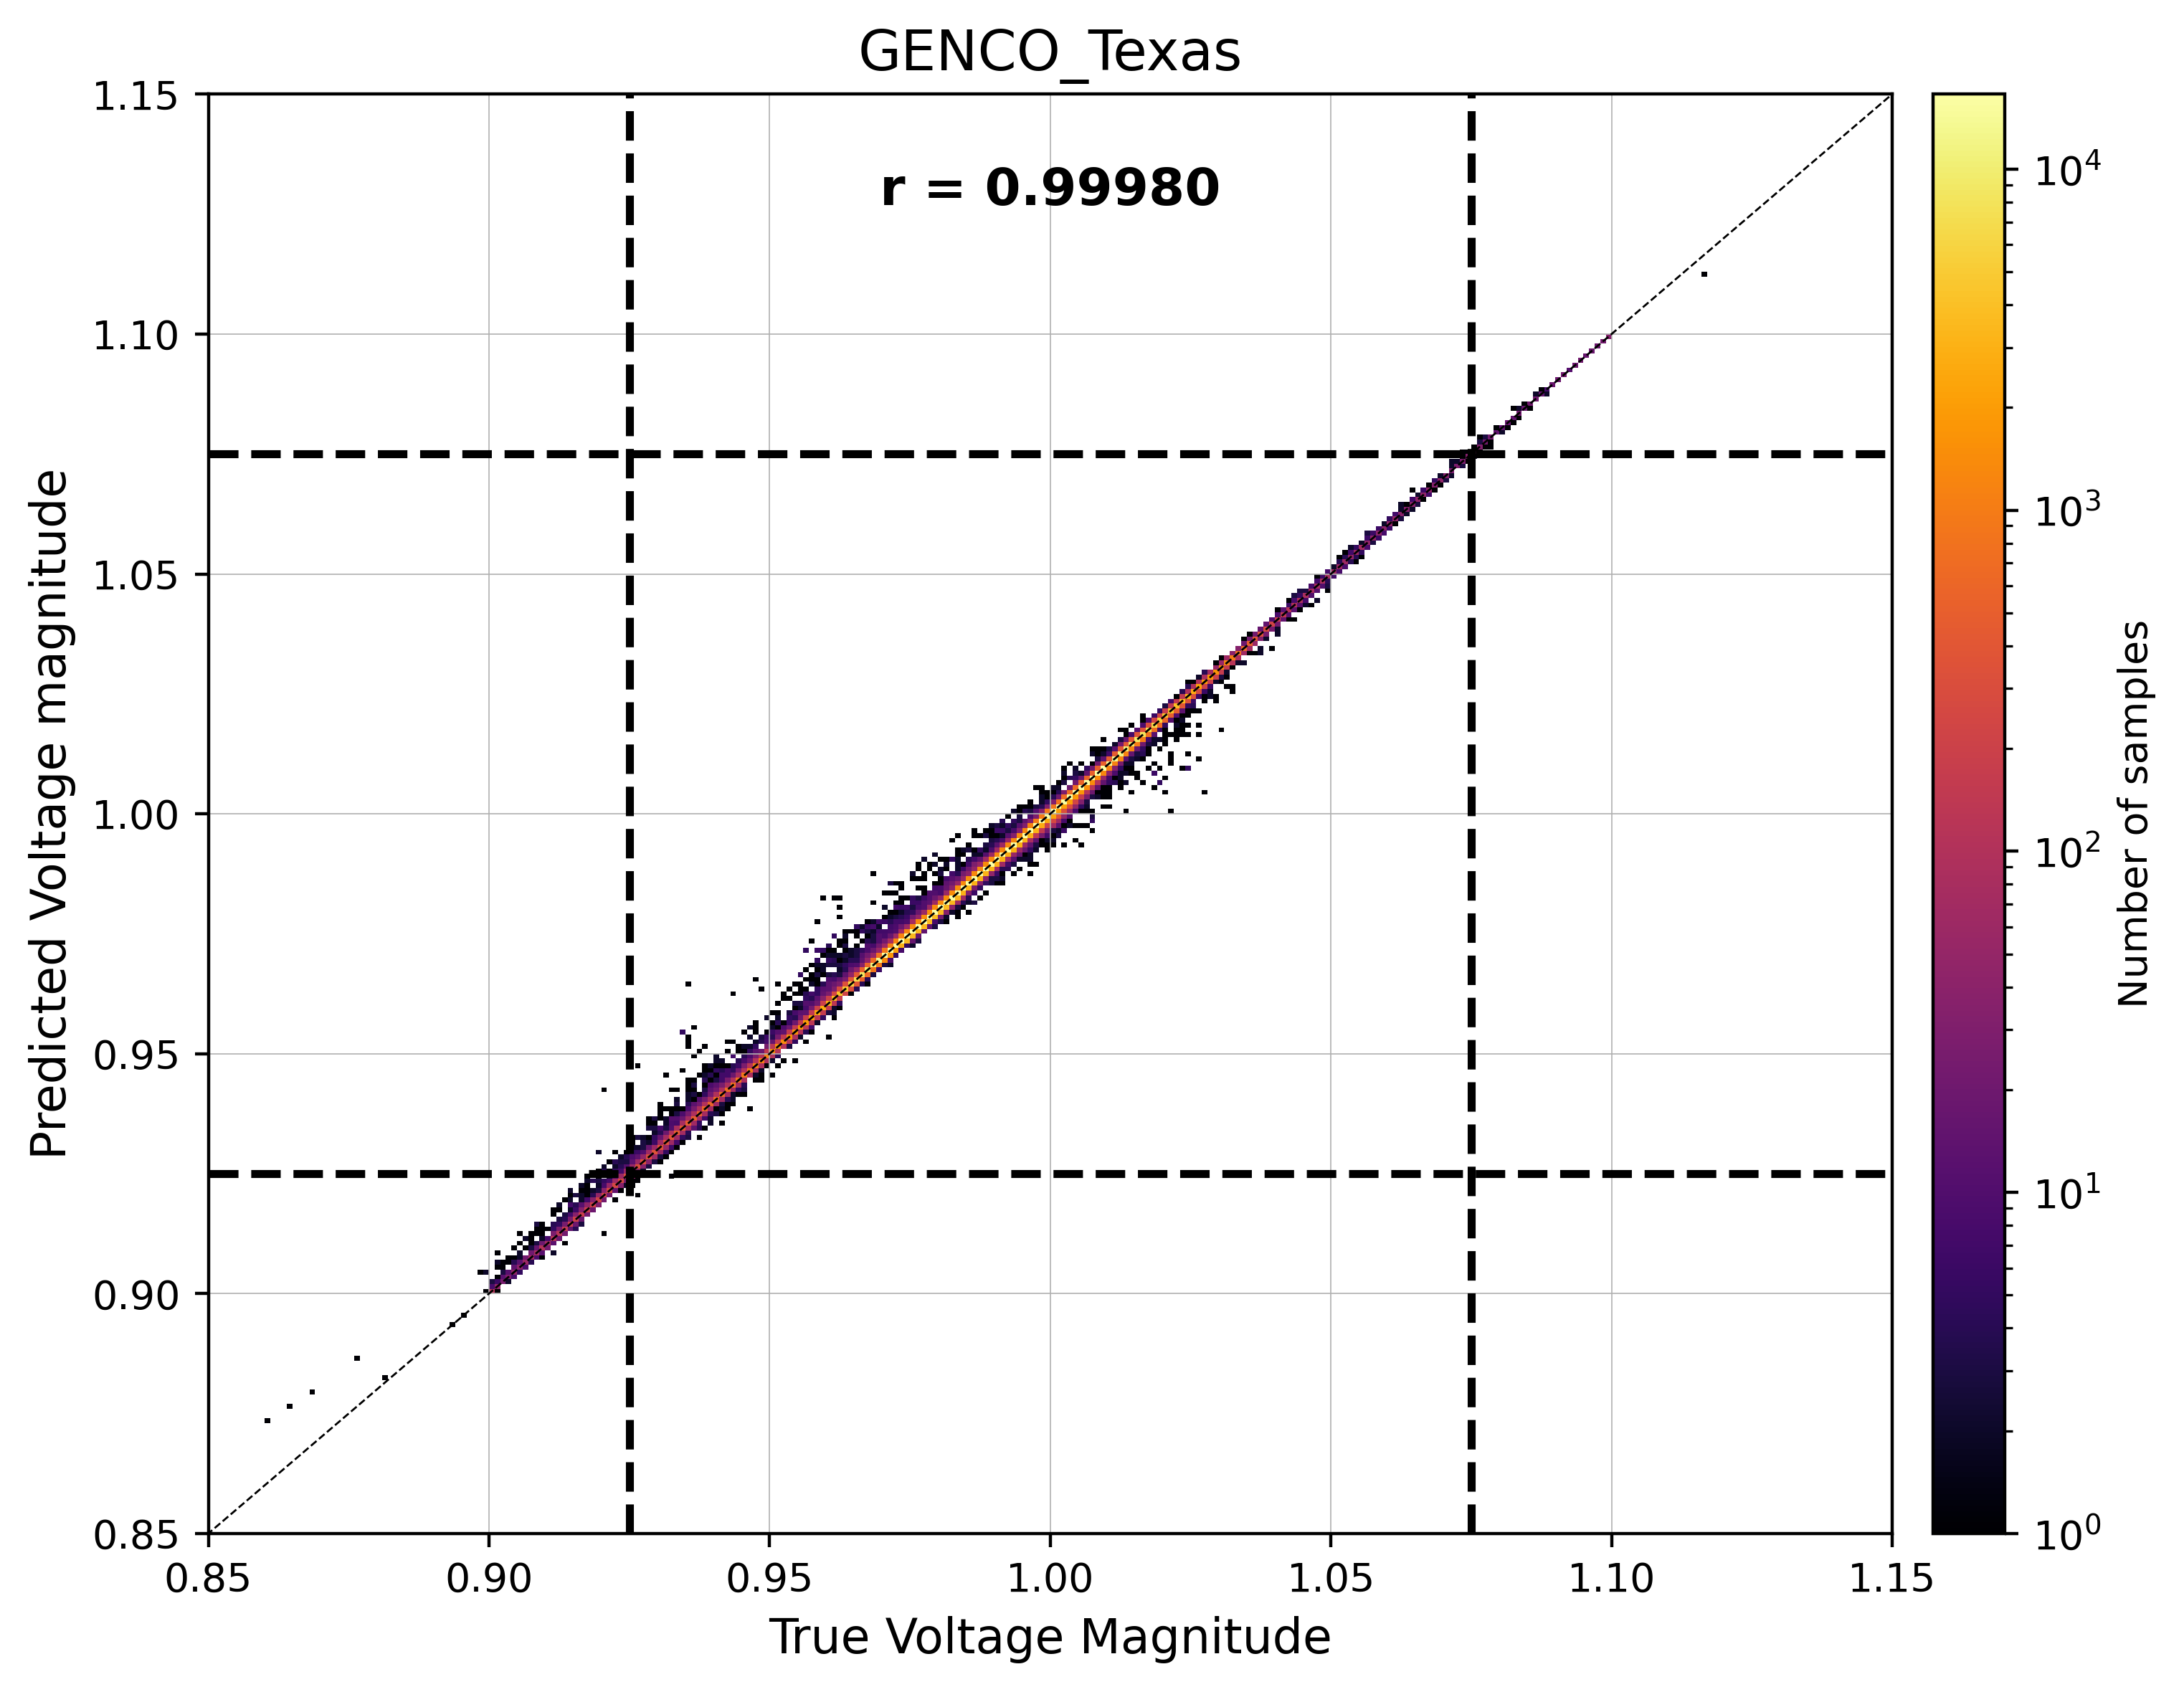

In [17]:
plot_mass_correlation_density_voltage(pf_node, prediction_label, label_plot, vm_nominal=1.0,
    vm_dev_threshold=0.075)

In [18]:
# Compute CM for Vm and Vm predicted
vm_dev_true = np.abs(pf_node["Vm"].to_numpy() - 1.0)
vm_dev_genco = np.abs(pf_node["Vm_pred_corrected"].to_numpy() - 1.0)
vm_violation_true = vm_dev_true > 0.075
vm_pred_genco = vm_dev_genco > 0.071

In [19]:
TP_genco_vm, FP_genco_vm, TN_genco_vm, FN_genco_vm = compute_cm_metrics(
    vm_violation_true, vm_pred_genco, "Vm violations", label_plot
)

Accuracy: 0.999
Confusion Matrix:
TP: 5500, FP: 1809, TN: 1730686, FN: 5
GENCO
TPR: 0.999 (percentage of overloadings correctly predicted)
FPR: 0.001 (percentage of non-overloadings predicted as overloadings)
TNR: 1.00
FNR: 0.00


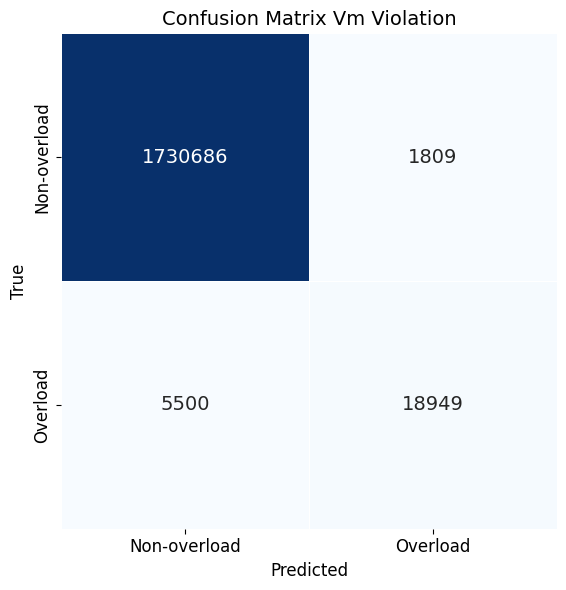

In [20]:
plot_cm(TN_genco_vm, FP_genco_vm, TP_genco_vm, TP_dc, "VM", "Vm Violation")
